# Train DeepONet on Fluent cell-center subdomains

This notebook uses the non-grid dataset. The trunk queries are original Fluent cell centers inside each subdomain, not a 256×256 raster grid. Branch sensors are exterior BC points plus interpolated interface points.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import builtins
import sys
import logging
import subprocess
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from datetime import datetime

MODULE_DIR = Path.cwd()

if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from deeponet_fluent_dataset import (
    build_fluent_deeponet_dataset,
    DeepONetCellDataset,
    deeponet_cell_collate_fn,
)

from fluent_deeponet import (
    FeatureNormalizer,
    DeepONet,
    train_deeponet_one_epoch,
    evaluate_deeponet,
    predict_cell_sample,
)

from plot import (
    plot_prediction_imshow_from_points,
    local_query_to_physical,
    collect_predictions_for_data,
)

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda:0


In [2]:
comment = "random interface, 20 subdomains, 5 realizations"

In [3]:
def save_git_snapshot(run_dir):
    run_dir = Path(run_dir)
    run_dir.mkdir(parents=True, exist_ok=True)

    commands = {
        "git_commit.txt": ["git", "rev-parse", "HEAD"],
        "git_status.txt": ["git", "status"],
        "git_diff.patch": ["git", "diff"],
        "git_diff_cached.patch": ["git", "diff", "--cached"],
    }

    for filename, command in commands.items():
        with open(run_dir / filename, "w", encoding="utf-8") as f:
            subprocess.run(command, stdout=f, stderr=subprocess.STDOUT)

today = datetime.now().strftime("%m%d%y")
output_root = Path("results")
output_root.mkdir(parents=True, exist_ok=True)
run_no = len([s for s in output_root.iterdir() if today in s.name]) + 1
output_str = f"{today}_{run_no}"
output_dir = output_root / output_str
output_dir.mkdir(parents=True, exist_ok=True)
save_git_snapshot(output_dir / "code_snapshot")
logger = logging.getLogger("pino")
logging.basicConfig(filename=output_dir / 'training.log', 
                    level=logging.INFO, 
                    force=True,
                    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
                    datefmt='%Y-%m-%d %H:%M:%S')

orig_print = builtins.print
def print(*args, sep=' ', end='\n', file=None, flush=False):
    orig_print(*args, sep=sep, end=end, file=file, flush=flush)
    msg = sep.join(map(str, args))
    logger.info(msg)
    
print("Training comment")
print(comment)

Training comment
random interface, 20 subdomains, 5 realizations


## Case file paths

In [4]:
ROOT_DIR = Path("/home/hantianl/Documents/PIDIF/")
DATASET_NAME = "channel_water"

def case_paths(ch):
    return {
        "design": ROOT_DIR / f"2d_geometry_specs/{DATASET_NAME}/{ch}.json",
        "mesh": ROOT_DIR / f"runs_2d/{DATASET_NAME}/{ch}/{ch}.msh.h5",
        "dat": ROOT_DIR / f"runs_2d/{DATASET_NAME}/{ch}/case2d.dat.h5",
    }

# Keep only cases whose design/mesh/dat files all exist (completed runs).
available_cases = [
    ch.name for ch in (ROOT_DIR / "runs_2d" / DATASET_NAME).iterdir()
    if all(case_paths(ch.name)[k].exists() for k in ("design", "mesh", "dat"))
]
case_files = {ch: case_paths(ch) for ch in available_cases}

print(f"Available cases ({len(available_cases)}):")
print(sorted([int(ch.split("_")[-1]) for ch in available_cases]))

Available cases (200):
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199]


# Training config

In [5]:
# 80/10/10 train/val/test split over the available cases (split by case id).
SPLIT_SEED = 0
_split_rng = np.random.default_rng(SPLIT_SEED)
_shuffled_cases = list(available_cases)
_split_rng.shuffle(_shuffled_cases)

n_total = len(_shuffled_cases)
n_train = int(round(0.80 * n_total))
n_valid = int(round(0.10 * n_total))
TRAIN_CASES = sorted(_shuffled_cases[:n_train])
VALID_CASES = sorted(_shuffled_cases[n_train:n_train + n_valid])
TEST_CASES = sorted(_shuffled_cases[n_train + n_valid:])

print(f"Train cases ({len(TRAIN_CASES)}):", TRAIN_CASES)
print(f"Valid cases ({len(VALID_CASES)}):", VALID_CASES)
print(f"Test  cases ({len(TEST_CASES)}):", TEST_CASES)

# Interfaces at fixed locations; n_sub adapts to each channel's aspect ratio.
N_SUBDOMAINS = 20
N_INTERFACE_POINTS = 256
N_WALL_POINTS = 256
INTERFACE_PLACEMENT = "random"
INTERFACE_JITTER = 0.0
MIN_SUBDOMAIN_WIDTH = 0.01
N_REALIZATIONS_TRAIN = 5

N_QUERY_TRAIN = None
N_QUERY_VALID = None
BATCH_SIZE = 50

# Isothermal runs have no temperature field: train on pressure/u/v only.
FIELD_MAP = {"pressure": "SV_P", "u": "SV_U", "v": "SV_V"}

LAMBDA_BC = 1.0
# inlet_u is intentionally omitted so each case uses its own Uin_mps (from its
# design config) as the inlet boundary condition.
bc_kwargs = {
    "inlet_v": 0.0,
    "outlet_p": 0.0,
    "wall_u": 0.0,
    "wall_v": 0.0,
}

Train cases (160): ['channel_00', 'channel_01', 'channel_02', 'channel_03', 'channel_04', 'channel_05', 'channel_06', 'channel_07', 'channel_09', 'channel_10', 'channel_100', 'channel_101', 'channel_102', 'channel_103', 'channel_104', 'channel_105', 'channel_106', 'channel_107', 'channel_108', 'channel_109', 'channel_11', 'channel_110', 'channel_112', 'channel_113', 'channel_114', 'channel_115', 'channel_116', 'channel_119', 'channel_12', 'channel_120', 'channel_121', 'channel_122', 'channel_123', 'channel_124', 'channel_125', 'channel_126', 'channel_127', 'channel_128', 'channel_129', 'channel_13', 'channel_130', 'channel_131', 'channel_132', 'channel_134', 'channel_135', 'channel_136', 'channel_137', 'channel_138', 'channel_139', 'channel_14', 'channel_140', 'channel_143', 'channel_144', 'channel_145', 'channel_146', 'channel_147', 'channel_148', 'channel_149', 'channel_15', 'channel_150', 'channel_152', 'channel_153', 'channel_155', 'channel_156', 'channel_157', 'channel_158', 'chan

## Build non-grid training/validation dataset

In [ ]:
train_data = build_fluent_deeponet_dataset(
    case_files=case_files,
    case_ids=TRAIN_CASES,
    n_subdomains=N_SUBDOMAINS,
    n_interface_points=N_INTERFACE_POINTS,
    n_boundary_points=N_WALL_POINTS,
    n_realizations=N_REALIZATIONS_TRAIN,
    interface_placement=INTERFACE_PLACEMENT,
    interface_jitter=INTERFACE_JITTER,
    min_subdomain_width=MIN_SUBDOMAIN_WIDTH,
    field_map=FIELD_MAP,
    bc_kwargs=bc_kwargs,
    keep_raw_case_data=False,
    rng=rng,
)

valid_data = build_fluent_deeponet_dataset(
    case_files=case_files,
    case_ids=VALID_CASES,
    n_subdomains=N_SUBDOMAINS,
    n_interface_points=N_INTERFACE_POINTS,
    n_boundary_points=N_WALL_POINTS,
    interface_placement="control_points",
    interface_jitter=0,
    field_map=FIELD_MAP,
    bc_kwargs=bc_kwargs,
    keep_raw_case_data=False,
    rng=rng,
)

samples = train_data["samples"]
metadata = train_data["metadata"]
branch_channel_names = list(train_data["branch_channel_names"])
trunk_channel_names = list(train_data["trunk_channel_names"])
output_channel_names = list(train_data["output_channel_names"])

ars = np.asarray([int(round(m["aspect_ratio"])) for m in metadata], dtype=np.int64)
subdomain_ids = np.asarray([int(m["subdomain_id"]) for m in metadata], dtype=np.int64)
local_aspect_ratios = np.asarray([float(m["local_aspect_ratio"]) for m in metadata], dtype=np.float32)
n_cells = np.asarray([int(m["n_cells"]) for m in metadata], dtype=np.int64)

print("Train samples:", len(train_data["samples"]))
print("Valid samples:", len(valid_data["samples"]))

print("Train branch channels:", train_data["branch_channel_names"])
print("Train trunk channels:", train_data["trunk_channel_names"])
print("Output channels:", train_data["output_channel_names"])

print("Example train sample:")
print("branch:", train_data["samples"][0]["branch"].shape)
print("query:", train_data["samples"][0]["query"].shape)
print("target:", train_data["samples"][0]["target"].shape)

Processing case channel_00 realization=0 (n_subdomains=20)
Processing case channel_00 realization=1 (n_subdomains=20)
Processing case channel_00 realization=2 (n_subdomains=20)
Processing case channel_00 realization=3 (n_subdomains=20)
Processing case channel_00 realization=4 (n_subdomains=20)
Processing case channel_01 realization=0 (n_subdomains=20)
Processing case channel_01 realization=1 (n_subdomains=20)
Processing case channel_01 realization=2 (n_subdomains=20)


In [ ]:
train_metadata = train_data["metadata"]
valid_metadata = valid_data["metadata"]

train_subdomain_ids = np.asarray(
    [m["subdomain_id"] for m in train_metadata],
    dtype=np.int64,
)

valid_subdomain_ids = np.asarray(
    [m["subdomain_id"] for m in valid_metadata],
    dtype=np.int64,
)

train_case_ids = sorted({int(m["case_id"].split("_")[-1]) for m in train_metadata})
valid_case_ids = sorted({int(m["case_id"].split("_")[-1]) for m in valid_metadata})

print("Train cases:", train_case_ids)
print("Valid cases:", valid_case_ids)

Train cases: [0, 1, 2, 4, 5, 6, 7, 8, 10, 12, 13, 15, 17, 19, 21, 22, 24, 26, 27, 28, 30, 31, 32, 33, 34, 36, 37, 38, 39, 40, 41, 42, 44, 45, 46, 47, 48, 50, 51, 53, 54, 56, 57, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 70, 71, 72, 74, 75, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 98, 99]
Valid cases: [9, 11, 16, 18, 20, 23, 29, 35, 43, 76]


In [ ]:
def concatenate_targets(data):
    return np.concatenate(
        [sample["target"] for sample in data["samples"]],
        axis=0,
    ).astype(np.float32)


train_targets_all = concatenate_targets(train_data)

y_normalizer = FeatureNormalizer(train_targets_all)

print("Y mean:", y_normalizer.mean)
print("Y std:", y_normalizer.std)

train_local_aspects = np.asarray(
    [m["local_aspect_ratio"] for m in train_data["metadata"]],
    dtype=np.float32,
)

local_aspect_mean = float(train_local_aspects.mean())
local_aspect_std = float(train_local_aspects.std() + 1.0e-6)

print("local_aspect_mean:", local_aspect_mean)
print("local_aspect_std:", local_aspect_std)

Y mean: tensor([ 6.3925e+02,  1.0017e+00, -1.2696e-05])
Y std: tensor([4.1504e+02, 4.2805e-01, 2.2184e-02])
local_aspect_mean: 0.5
local_aspect_std: 0.3750267028808594


## DataLoaders

In [ ]:
train_ds = DeepONetCellDataset(
    samples=train_data["samples"],
    sample_indices=None,
    n_query_points=N_QUERY_TRAIN,
    random_query=True,
    target_y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    branch_channel_names=train_data["branch_channel_names"],
)

valid_ds = DeepONetCellDataset(
    samples=valid_data["samples"],
    sample_indices=None,
    n_query_points=N_QUERY_VALID,
    random_query=False,
    target_y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    branch_channel_names=valid_data["branch_channel_names"],
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    collate_fn=deeponet_cell_collate_fn,
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    collate_fn=deeponet_cell_collate_fn,
)

branch_batch, query_batch, target_batch, query_batch_id, sample_idx_batch = next(iter(train_loader))

print("branch batch:", branch_batch.shape)
print("query batch:", query_batch.shape)
print("target batch:", target_batch.shape)
print("query batch id:", query_batch_id.min(), query_batch_id.max())
print("sample indices:", sample_idx_batch)

branch batch: torch.Size([50, 1024, 11])
query batch: torch.Size([613027, 2])
target batch: torch.Size([613027, 3])
query batch id: tensor(0) tensor(49)
sample indices: tensor([7226,   72, 7865, 1312, 4485, 1301,  771, 3774, 1648, 1242, 4281, 6456,
        1766, 2673, 2809, 5218, 5811, 1282, 1259, 3348, 6148,  315, 2411, 6341,
        5227, 7809, 5036, 5123, 4883, 5172, 4926, 1584,  343, 4365, 7100, 3947,
        6879, 2735,  231, 3038,  911, 5536, 4052,   57, 7051,  658, 5496, 4708,
        4424, 6193])


## Model

In [ ]:
branch_input_dim = train_data["samples"][0]["branch"].shape[-1]
trunk_input_dim = train_data["samples"][0]["query"].shape[-1]
output_channels = train_data["samples"][0]["target"].shape[-1]

model = DeepONet(
    branch_input_dim=branch_input_dim,
    trunk_input_dim=trunk_input_dim,
    output_channels=output_channels,
    latent_dim=128,
    branch_point_hidden_dim=128,
    branch_point_depth=3,
    branch_global_hidden_dim=128,
    branch_global_depth=3,
    trunk_hidden_dim=128,
    trunk_depth=4,
    aggregation="mean",
    activation="gelu",
    layer_norm=False,
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=1.0e-3, weight_decay=1.0e-4)
EPOCHS = 1000
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(model.config())

{'branch_input_dim': 11, 'trunk_input_dim': 2, 'output_channels': 3, 'latent_dim': 128, 'branch_point_hidden_dim': 128, 'branch_point_depth': 3, 'branch_global_hidden_dim': 128, 'branch_global_depth': 3, 'trunk_hidden_dim': 128, 'trunk_depth': 4, 'aggregation': 'mean', 'activation': 'gelu', 'layer_norm': False}


## Train

In [ ]:
checkpoint_path = output_dir / "checkpoint.pt"

LOSS_TYPE = "mse"

best_valid_mse = float("inf")
history = []
y_normalizer = y_normalizer.to(DEVICE)

start = datetime.now()
for epoch in range(1, EPOCHS + 1):
    data_loss, bc_loss = train_deeponet_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=DEVICE,
        loss_type=LOSS_TYPE,
        lambda_bc=LAMBDA_BC,
        branch_channel_names=branch_channel_names,
        output_channel_names=output_channel_names,
    )
    scheduler.step()

    valid_metrics = evaluate_deeponet(
        model=model,
        loader=valid_loader,
        device=DEVICE,
        y_normalizer=y_normalizer,
    )
    valid_mse = valid_metrics["mse"]
    valid_rel = valid_metrics["relative_l2"]
    valid_channel_rel = valid_metrics["channel_relative_l2"]

    history.append({
        "epoch": epoch,
        "data_loss": data_loss,
        "bc_loss": bc_loss,
        "valid_mse": valid_mse,
        "valid_relative_l2": valid_rel,
        "valid_channel_relative_l2": valid_channel_rel,
    })

    if valid_mse < best_valid_mse:
        best_valid_mse = valid_mse
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "model_config": model.config(),
                "y_normalizer": y_normalizer.state_dict(),
                "branch_channel_names": train_data["branch_channel_names"],
                "trunk_channel_names": train_data["trunk_channel_names"],
                "output_channel_names": train_data["output_channel_names"],
                "train_cases": TRAIN_CASES,
                "valid_cases": VALID_CASES,
                "test_cases": TEST_CASES,
                "n_subdomains": N_SUBDOMAINS,
                "field_map": FIELD_MAP,
                "n_interface_points": N_INTERFACE_POINTS,
                "n_wall_points": N_WALL_POINTS,
                "interface_placement": INTERFACE_PLACEMENT,
                "interface_jitter": INTERFACE_JITTER,
                "min_subdomain_width": MIN_SUBDOMAIN_WIDTH,
                "local_aspect_mean": local_aspect_mean,
                "local_aspect_std": local_aspect_std,
                "bc_kwargs": bc_kwargs,
            },
            checkpoint_path,
        )

    if epoch == 1 or epoch % 10 == 0:
        channel_msg = ", ".join(f"{name}={err:.3e}" for name, err in zip(output_channel_names, valid_channel_rel))
        print(
            f"Epoch {epoch:04d} | data loss={data_loss:.3e} | bc loss={bc_loss:.3e} | "
            f"valid MSE={valid_metrics['mse']:.3e} | valid rel L2={valid_rel:.3e} | {channel_msg} | "
            f"Time: {datetime.now() - start}"
        )

print("Best validation MSE:", best_valid_mse)
print("Saved:", checkpoint_path)

loss_history_path = output_dir / f"loss_history.npz"
np.savez(
    loss_history_path,
    epoch=np.asarray([h["epoch"] for h in history], dtype=np.int32),
    data_loss=np.asarray([h["data_loss"] for h in history], dtype=np.float32),
    bc_loss=np.asarray([h["bc_loss"] for h in history], dtype=np.float32),
    valid_mse_phys=np.asarray([h["valid_mse"] for h in history], dtype=np.float32),
)

Epoch 0001 | data loss=5.703e-01 | bc loss=5.306e-01 | valid MSE=3.078e-01 | valid rel L2=4.442e-01 | pressure=1.107e-01, u=1.198e-01, v=8.211e-01 | Time: 0:00:24.338361
Epoch 0010 | data loss=7.499e-02 | bc loss=4.530e-02 | valid MSE=7.513e-02 | valid rel L2=1.594e-01 | pressure=3.445e-02, u=3.993e-02, v=4.222e-01 | Time: 0:04:02.521872
Epoch 0020 | data loss=4.490e-02 | bc loss=2.890e-02 | valid MSE=3.771e-02 | valid rel L2=1.187e-01 | pressure=3.145e-02, u=2.727e-02, v=2.944e-01 | Time: 0:07:56.571721
Epoch 0030 | data loss=2.447e-02 | bc loss=1.478e-02 | valid MSE=2.596e-02 | valid rel L2=9.895e-02 | pressure=2.126e-02, u=2.562e-02, v=2.370e-01 | Time: 0:12:04.068402
Epoch 0040 | data loss=2.712e-02 | bc loss=1.828e-02 | valid MSE=1.659e-02 | valid rel L2=7.847e-02 | pressure=2.067e-02, u=1.748e-02, v=1.944e-01 | Time: 0:16:05.761701
Epoch 0050 | data loss=1.452e-02 | bc loss=1.075e-02 | valid MSE=1.584e-02 | valid rel L2=7.763e-02 | pressure=2.051e-02, u=1.722e-02, v=1.890e-01 | T

Epoch 0400 | data loss=9.158e-04 | bc loss=8.785e-04 | valid MSE=8.991e-04 | valid rel L2=2.398e-02 | pressure=6.738e-03, u=7.201e-03, v=4.300e-02 | Time: 2:48:46.953779
Epoch 0410 | data loss=7.704e-04 | bc loss=9.758e-04 | valid MSE=5.791e-04 | valid rel L2=1.880e-02 | pressure=4.296e-03, u=6.675e-03, v=3.514e-02 | Time: 2:52:59.405036
Epoch 0420 | data loss=1.087e-03 | bc loss=1.418e-03 | valid MSE=2.094e-03 | valid rel L2=2.354e-02 | pressure=6.615e-03, u=6.015e-03, v=5.933e-02 | Time: 2:57:04.156714
Epoch 0430 | data loss=7.943e-04 | bc loss=1.042e-03 | valid MSE=2.281e-03 | valid rel L2=3.431e-02 | pressure=1.163e-02, u=1.317e-02, v=5.794e-02 | Time: 3:01:13.554277
Epoch 0440 | data loss=4.999e-04 | bc loss=4.598e-04 | valid MSE=4.604e-04 | valid rel L2=1.597e-02 | pressure=5.006e-03, u=4.422e-03, v=3.177e-02 | Time: 3:05:20.655152
Epoch 0450 | data loss=4.643e-04 | bc loss=3.395e-04 | valid MSE=3.856e-04 | valid rel L2=1.464e-02 | pressure=4.148e-03, u=3.846e-03, v=2.938e-02 | T

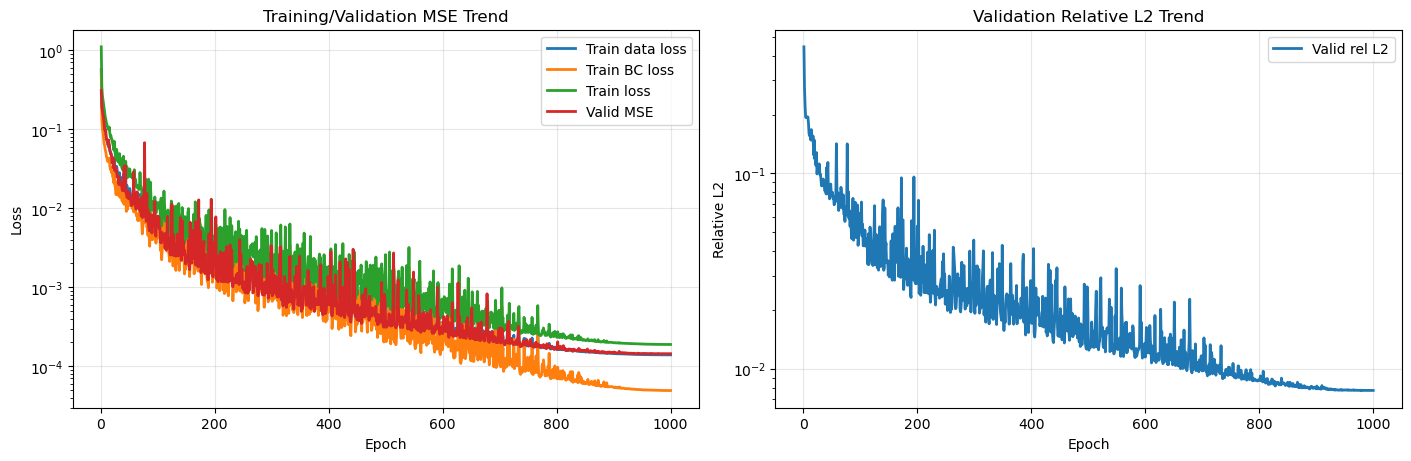

In [ ]:
# Plot training/validation loss trend over iterations (epochs).
epochs = np.asarray([h["epoch"] for h in history])
data_loss_arr = np.asarray([h["data_loss"] for h in history])
bc_loss_arr = np.asarray([h["bc_loss"] for h in history])
train_loss_arr = data_loss_arr + bc_loss_arr
valid_loss_arr = np.asarray([h["valid_mse"] for h in history])
valid_rel_l2_arr = np.asarray([h["valid_relative_l2"] for h in history])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

axes[0].plot(epochs, data_loss_arr, label="Train data loss", linewidth=2)
axes[0].plot(epochs, bc_loss_arr, label="Train BC loss", linewidth=2)
axes[0].plot(epochs, train_loss_arr, label="Train loss", linewidth=2)
axes[0].plot(epochs, valid_loss_arr, label="Valid MSE", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training/Validation MSE Trend")
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale("log")
axes[0].legend()

axes[1].plot(epochs, valid_rel_l2_arr, label="Valid rel L2", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Relative L2")
axes[1].set_title("Validation Relative L2 Trend")
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale("log")
axes[1].legend()
plt.savefig(output_dir / "loss_history.png")
plt.show()


## Load best checkpoint

In [ ]:
ckpt = torch.load(checkpoint_path, map_location=DEVICE)

best_model = DeepONet(**ckpt["model_config"]).to(DEVICE)
best_model.load_state_dict(ckpt["model_state_dict"])
best_model.eval()

y_normalizer = FeatureNormalizer.from_state_dict(ckpt["y_normalizer"]).to(DEVICE)
local_aspect_mean = float(ckpt["local_aspect_mean"])
local_aspect_std = float(ckpt["local_aspect_std"])

print("Loaded:", checkpoint_path)

Loaded: results/060926_2/checkpoint.pt


/tmp/ipykernel_424195/1104796799.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_location=DEVICE)


## Predict validation case

In [ ]:
output_channel_names = list(valid_data["output_channel_names"])
    
for c in VALID_CASES:
    valid_case_sample_ids = sorted(
        (i for i, mm in enumerate(valid_data["metadata"]) if mm["case_id"] == c),
        key=lambda i: int(valid_data["metadata"][i]["subdomain_id"]),
    )
    metadata = valid_data["metadata"][valid_case_sample_ids[0]]

    plot_data = collect_predictions_for_data(
        model=model,
        data=valid_data,
        device=DEVICE,
        y_normalizer=y_normalizer,
        local_aspect_mean=local_aspect_mean,
        local_aspect_std=local_aspect_std,
        sample_indices=valid_case_sample_ids,
    )

    print("Total plotted points:", plot_data["x"].shape[0])
    print("x range:", plot_data["x"].min(), plot_data["x"].max())
    print("y range:", plot_data["y"].min(), plot_data["y"].max())

    for field_name in output_channel_names:
        field_idx = output_channel_names.index(field_name)

        plot_prediction_imshow_from_points(
            x=plot_data["x"],
            y=plot_data["y"],
            pred=plot_data["pred"],
            truth=plot_data["truth"],
            field_name=field_name,
            field_idx=field_idx,
            n_x_plot=2000,
            n_y_plot=200,
            metadata=plot_data["metadata"],
            mesh_h5=case_files[metadata["case_id"]]["mesh"],
            output_dir=output_dir / "predictions" / "validation",
            filename_prefix=f"valid_case{int(c.split('_')[-1]):02d}",
        )

# Predict test case

In [ ]:
test_data = build_fluent_deeponet_dataset(
    case_files=case_files,
    case_ids=TEST_CASES,
    n_subdomains="adaptive",
    n_interface_points=N_INTERFACE_POINTS,
    n_boundary_points=N_WALL_POINTS,
    interface_placement="control_points",
    interface_jitter=0,
    field_map=FIELD_MAP,
    bc_kwargs=bc_kwargs,
    keep_raw_case_data=False,
    rng=rng,
)
print("Test samples:", len(test_data["samples"]))
print("Test cases:", sorted({int(m["case_id"].split("_")[-1]) for m in test_data["metadata"]}))

In [ ]:
for c in TEST_CASES:
    sample_test_ids = sorted(
        (i for i, mm in enumerate(test_data["metadata"]) if mm["case_id"] == c),
        key=lambda i: int(test_data["metadata"][i]["subdomain_id"]),
    )
    metadata = test_data["metadata"][sample_test_ids[0]]
    

    plot_data = collect_predictions_for_data(
        model=model,
        data=test_data,
        device=DEVICE,
        y_normalizer=y_normalizer,
        local_aspect_mean=local_aspect_mean,
        local_aspect_std=local_aspect_std,
        sample_indices=sample_test_ids,
    )

    print("Total plotted points:", plot_data["x"].shape[0])
    print("x range:", plot_data["x"].min(), plot_data["x"].max())
    print("y range:", plot_data["y"].min(), plot_data["y"].max())

    for field_name in output_channel_names:
        field_idx = output_channel_names.index(field_name)

        plot_prediction_imshow_from_points(
            x=plot_data["x"],
            y=plot_data["y"],
            pred=plot_data["pred"],
            truth=plot_data["truth"],
            field_name=field_name,
            field_idx=field_idx,
            metadata=plot_data["metadata"],
            n_y_plot=200,
            output_dir=output_dir / "predictions" / "test",
            filename_prefix=f"test_case{int(c.split('_')[-1]):02d}",
            mesh_h5=case_files[test_data["metadata"][sample_test_ids[0]]["case_id"]]["mesh"],
        )